In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings; warnings.filterwarnings('ignore')

In [2]:
ratings = pd.read_csv(
    r"C:\Users\LOQ\Desktop\Project 2\data\raw\rating.csv",
    usecols=['userId', 'movieId', 'rating'],
    dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'}
)
ratings.head()

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5
2,1,32,3.5
3,1,47,3.5
4,1,50,3.5


In [3]:
movies = pd.read_csv(r"C:\Users\LOQ\Desktop\Project 2\data\raw\movie.csv")

title_of = dict(zip(movies.movieId, movies.title))
genre_of = dict(zip(movies.movieId, movies.genres))

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
n_users  = ratings.userId.nunique()
n_movies = ratings.movieId.nunique()
n_ratings = len(ratings)

print(f"Users   : {n_users:,}")
print(f"Movies  : {n_movies:,}")
print(f"Ratings : {n_ratings:,}")
print(f"If everyone rated everything we'd have {n_users*n_movies:,} ratings.")
print(f"We only have {100*n_ratings/(n_users*n_movies):.3f}% of them filled in.")

Users   : 138,493
Movies  : 26,744
Ratings : 20,000,263
If everyone rated everything we'd have 3,703,856,792 ratings.
We only have 0.540% of them filled in.


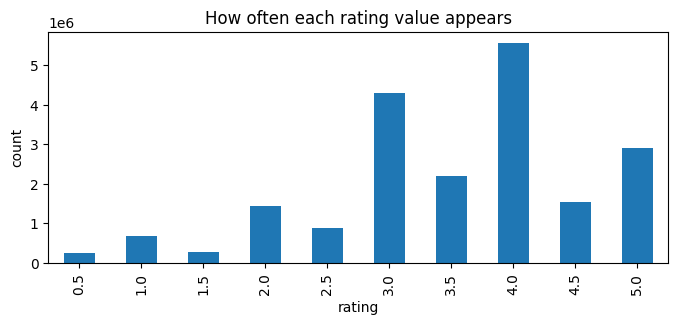

In [5]:
ratings.rating.value_counts().sort_index().plot(
    kind='bar', figsize=(8,3), title='How often each rating value appears')
plt.xlabel('rating'); plt.ylabel('count'); plt.show()

In [6]:
DEV_MODE  = True       # True = fast learning sample; False = full dataset
DEV_USERS = 10_000

if DEV_MODE:
    rng = np.random.default_rng(0)
    sample = rng.choice(ratings.userId.unique(),
                        size=min(DEV_USERS, n_users), replace=False)
    ratings = ratings[ratings.userId.isin(sample)].copy()
    print(f"Sampled down to {len(ratings):,} ratings")

Sampled down to 1,455,648 ratings


In [7]:
MIN_RATINGS = 50

movie_counts = ratings.movieId.value_counts()
user_counts  = ratings.userId.value_counts()

ratings = ratings[
    ratings.movieId.isin(movie_counts[movie_counts >= MIN_RATINGS].index) &
    ratings.userId.isin(user_counts[user_counts >= MIN_RATINGS].index)
].copy()

print("After filtering:", ratings.shape)
print("Users:", ratings.userId.nunique(), "| Movies:", ratings.movieId.nunique())

After filtering: (1225136, 3)
Users: 6227 | Movies: 3893


In [8]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
print("Data is ready for Surprise")

Data is ready for Surprise


In [9]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
print("Training ratings:", trainset.n_ratings)
print("Testing ratings :", len(testset))

Training ratings: 980108
Testing ratings : 245028


In [10]:
from surprise import accuracy

results = []   # we'll collect every algorithm's scores here

def evaluate(name, algo):
    algo.fit(trainset)                       # 1. learn from training data
    predictions = algo.test(testset)         # 2. predict the hidden test ratings
    rmse = accuracy.rmse(predictions, verbose=False)   # 3. score
    mae  = accuracy.mae(predictions,  verbose=False)
    results.append({'Algorithm': name, 'RMSE': round(rmse,4), 'MAE': round(mae,4)})
    print(f"{name:18s}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return algo

# Base-Line Model

In [11]:
from surprise import NormalPredictor

evaluate("Random baseline", NormalPredictor());

Random baseline     RMSE=1.4184  MAE=1.1302


# KNN item-based

In [12]:
from surprise import KNNWithMeans

# Item-based: similarity between movies
evaluate("KNN item-based",
         KNNWithMeans(k=40, sim_options={'name':'cosine', 'user_based':False}));

Computing the cosine similarity matrix...
Done computing similarity matrix.
KNN item-based      RMSE=0.8364  MAE=0.6398


# KNN user-based

In [13]:
# User-based: similarity between users
evaluate("KNN user-based",
         KNNWithMeans(k=40, sim_options={'name':'cosine', 'user_based':True}));

Computing the cosine similarity matrix...
Done computing similarity matrix.
KNN user-based      RMSE=0.8693  MAE=0.6738


# SVD

In [14]:
from surprise import SVD

svd = evaluate("SVD",
               SVD(n_factors=50, n_epochs=20, random_state=42))

SVD                 RMSE=0.8074  MAE=0.6172


# Matrix Factorization

In [15]:
from surprise import NMF

evaluate("NMF", NMF(n_factors=15, n_epochs=50, random_state=42));

NMF                 RMSE=0.8589  MAE=0.6610


# Perforamnce Comprasion of Each MODEL

In [16]:
leaderboard = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
leaderboard

,Algorithm,RMSE,MAE
0,SVD,0.8074,0.6172
1,KNN item-based,0.8364,0.6398
2,NMF,0.8589,0.6610
3,KNN user-based,0.8693,0.6738
4,Random baseline,1.4184,1.1302


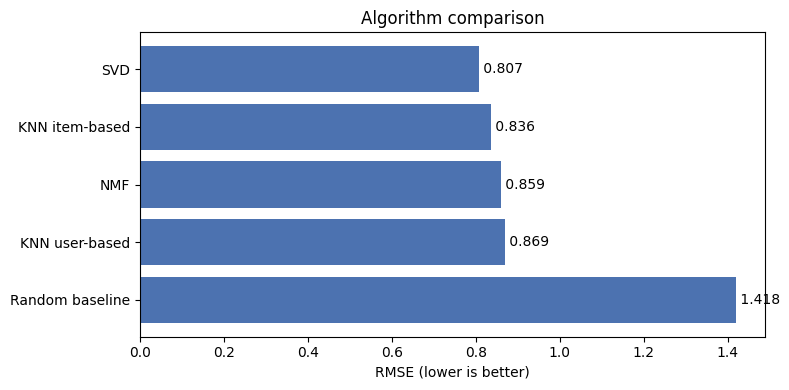

In [17]:
plt.figure(figsize=(8,4))
plt.barh(leaderboard.Algorithm, leaderboard.RMSE, color='#4C72B0')
plt.gca().invert_yaxis()
plt.xlabel('RMSE (lower is better)'); plt.title('Algorithm comparison')
for i, v in enumerate(leaderboard.RMSE):
    plt.text(v, i, f' {v:.3f}', va='center')
plt.tight_layout(); plt.show()

# With be best output - SVD model goes to the production line

In [18]:
final_model = SVD(n_factors=50, n_epochs=20, random_state=42)
full_trainset = data.build_full_trainset()
final_model.fit(full_trainset)
print("Final model trained on all", full_trainset.n_ratings, "ratings")

Final model trained on all 1225136 ratings


In [19]:
user_id  = ratings.userId.iloc[0]
movie_id = ratings.movieId.iloc[0]
pred = final_model.predict(user_id, movie_id)
print(f"User {user_id} -> '{title_of.get(movie_id, movie_id)}': predicted {pred.est:.2f} stars")

User 3 -> 'Toy Story (1995)': predicted 4.41 stars


In [20]:
all_movies = ratings.movieId.unique()

def recommend_for_user(user_id, n=10):
    seen = set(ratings.loc[ratings.userId == user_id, 'movieId'])

    scored = []
    for movie_id in all_movies:
        if movie_id not in seen:
            est = final_model.predict(user_id, movie_id).est
            scored.append((movie_id, est))

    scored.sort(key=lambda x: x[1], reverse=True)         
    top = scored[:n]
    return pd.DataFrame({
        'title': [title_of.get(m, m) for m, _ in top],
        'predicted_rating': [round(e, 2) for _, e in top]
    })

recommend_for_user(ratings.userId.iloc[0], 10)

,title,predicted_rating
0,Braveheart (1995),5.00
1,"Lord of the Rings: The Two Towers, The (2002)",5.00
2,"Lord of the Rings: The Return of the King, The...",5.00
3,Cosmos (1980),5.00
4,Band of Brothers (2001),4.99
5,Casablanca (1942),4.94
6,"Lord of the Rings: The Fellowship of the Ring,...",4.91
7,Monty Python and the Holy Grail (1975),4.89
8,Ikiru (1952),4.88
9,"Best Years of Our Lives, The (1946)",4.88


In [21]:
from sklearn.metrics.pairwise import cosine_similarity

# every movie's learned factor vector, and a map from movieId -> its row
movie_factors    = final_model.qi
movie_ids        = [full_trainset.to_raw_iid(i) for i in range(full_trainset.n_items)]
row_of_movie     = {m: i for i, m in enumerate(movie_ids)}

# similarity between every pair of movies (cosine of their factor vectors)
movie_similarity = cosine_similarity(movie_factors)
print("Built similarity for", len(movie_ids), "movies")

Built similarity for 3893 movies


In [22]:
def similar_movies(movie_id, n=10):
    if movie_id not in row_of_movie:
        return "that movie isn't in the model"
    i = row_of_movie[movie_id]
    order = np.argsort(movie_similarity[i])[::-1]      # most similar first
    order = [j for j in order if j != i][:n]           # skip the movie itself
    return pd.DataFrame({
        'title':      [title_of.get(movie_ids[j], movie_ids[j]) for j in order],
        'similarity': [round(float(movie_similarity[i][j]), 3) for j in order]
    })

# try it
pick = ratings.movieId.iloc[0]
print("Because you liked:", title_of.get(pick, pick))
similar_movies(pick, 10)

Because you liked: Toy Story (1995)


,title,similarity
0,Toy Story 2 (1999),0.889
1,"Monsters, Inc. (2001)",0.739
2,"Incredibles, The (2004)",0.672
3,Finding Nemo (2003),0.626
4,"Bug's Life, A (1998)",0.621
5,Aladdin (1992),0.618
6,Ratatouille (2007),0.587
7,Beauty and the Beast (1991),0.584
8,101 Dalmatians (One Hundred and One Dalmatians...,0.584
9,Toy Story 3 (2010),0.541


In [23]:
# ============================================================================
#  ADD THIS AS A NEW CELL AT THE END OF YOUR NOTEBOOK
#  (after `final_model` has been trained on `full_trainset`)
#
#  It saves 3 small files that the web app needs:
#    recommender_data.npz  - the learned SVD numbers (tiny)
#    movies_meta.csv       - movieId, title, genres
#    user_seen.json        - movies each user already rated (to skip them)
# ============================================================================
import numpy as np, json, os

os.makedirs("deploy", exist_ok=True)
ts = full_trainset

# inner-id order -> raw ids, so the app can map a real id to a row
user_raw  = np.array([ts.to_raw_uid(i) for i in range(ts.n_users)])
movie_raw = np.array([ts.to_raw_iid(i) for i in range(ts.n_items)])

# 1) the model = a few small matrices
np.savez_compressed(
    "deploy/recommender_data.npz",
    mu=ts.global_mean,
    bu=final_model.bu, bi=final_model.bi,     # user / item biases
    pu=final_model.pu, qi=final_model.qi,     # user / item latent factors
    user_raw=user_raw, movie_raw=movie_raw,
)

# 2) movie metadata (only the movies the model knows), most popular first
pop  = ratings.movieId.value_counts()
meta = movies[movies.movieId.isin(set(movie_raw.tolist()))].copy()
meta["pop"] = meta.movieId.map(pop).fillna(0)
meta.sort_values("pop", ascending=False)[["movieId", "title", "genres"]] \
    .to_csv("deploy/movies_meta.csv", index=False)

# 3) what each user already rated
seen = ratings.groupby("userId")["movieId"].apply(lambda s: [int(x) for x in s]).to_dict()
json.dump({int(k): v for k, v in seen.items()}, open("deploy/user_seen.json", "w"))

print("Saved to ./deploy/ :")
for f in os.listdir("deploy"):
    print(f"  {f}  ({os.path.getsize('deploy/'+f)/1024:.0f} KB)")
print("\nCopy these 3 files next to app.py to run the website.")


Saved to ./deploy/ :
  movies_meta.csv  (192 KB)
  recommender_data.npz  (3880 KB)
  user_seen.json  (6988 KB)

Copy these 3 files next to app.py to run the website.
